# Movie Review Sentiment Analysis — Exploratory Data Analysis

Binary sentiment classification of IMDB movie reviews (50,000 reviews, balanced positive/negative). Reviews contain HTML line breaks that are stripped during cleaning.

**Text column:** `review`  |  **Label column:** `sentiment`

## 1. Imports & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings; warnings.filterwarnings('ignore')
from collections import Counter
sns.set_style('whitegrid')
pd.set_option('display.max_colwidth', 120)
%matplotlib inline

In [2]:
from utils import load_data
df = load_data()
print('Shape:', df.shape)
df.head()

Shape: (50000, 2)


,review,sentiment
0,"One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as ...",positive
1,A wonderful little production. <br /><br />The filming technique is very unassuming- very old-time-BBC fashion and g...,positive
2,"I thought this was a wonderful way to spend time on a too hot summer weekend, sitting in the air conditioned theater...",positive
3,Basically there's a family where a little boy (Jake) thinks there's a zombie in his closet & his parents are fightin...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is a visually stunning film to watch. Mr. Mattei offers us a vivid portr...",positive


## 2. Dataset Overview

In [3]:
print('Shape:', df.shape)
print('\nColumns:', list(df.columns))
print('\nDtypes:')
print(df.dtypes)

Shape: (50000, 2)

Columns: ['review', 'sentiment']

Dtypes:
review       object
sentiment    object
dtype: object


In [4]:
print('Duplicate rows:', df.duplicated().sum())
print('Missing per column:'); print(df.isnull().sum())

Duplicate rows: 418
Missing per column:
review       0
sentiment    0
dtype: int64


## 3. Target / Label Distribution

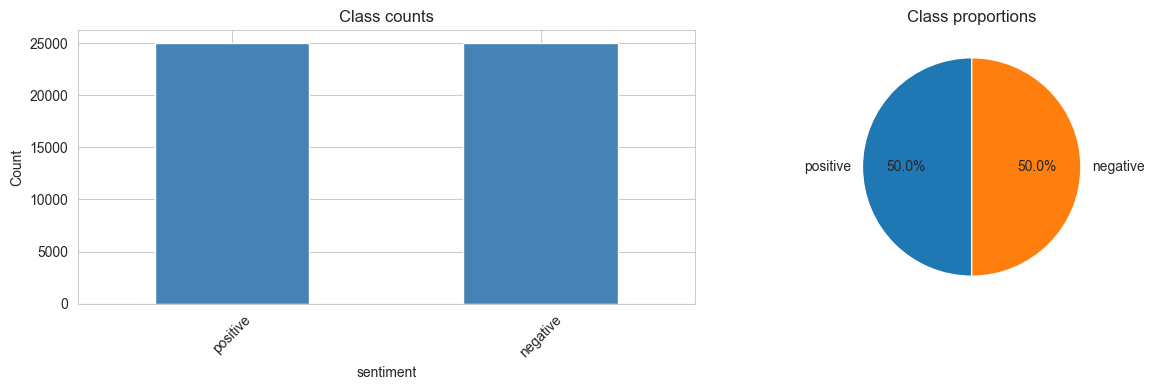

Class balance (%):
sentiment
positive    50.0
negative    50.0
Name: count, dtype: float64


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
counts = df['sentiment'].value_counts()
counts.plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Class counts'); axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)
axes[1].pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=90)
axes[1].set_title('Class proportions')
plt.tight_layout(); plt.show()
print('Class balance (%):')
print((counts / counts.sum() * 100).round(2))

## 4. Text Length Analysis

In [6]:
df['char_count'] = df['review'].astype(str).str.len()
df['word_count'] = df['review'].astype(str).str.split().str.len()
df[['char_count', 'word_count']].describe().round(1)

,char_count,word_count
count,50000.0,50000.0
mean,1309.4,231.2
std,989.7,171.3
min,32.0,4.0
25%,699.0,126.0
50%,970.0,173.0
75%,1590.2,280.0
max,13704.0,2470.0


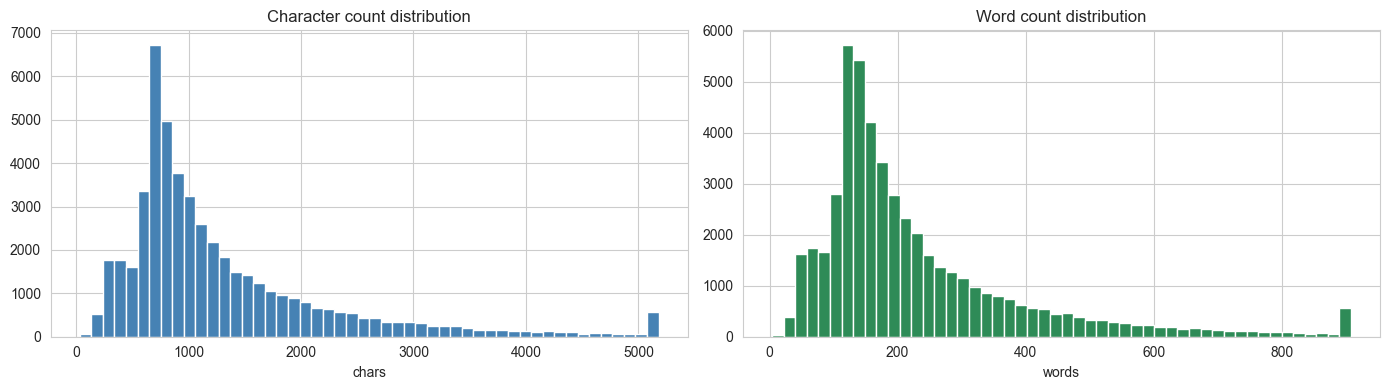

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
df['char_count'].clip(upper=df['char_count'].quantile(0.99)).hist(bins=50, ax=axes[0], color='steelblue')
axes[0].set_title('Character count distribution'); axes[0].set_xlabel('chars')
df['word_count'].clip(upper=df['word_count'].quantile(0.99)).hist(bins=50, ax=axes[1], color='seagreen')
axes[1].set_title('Word count distribution'); axes[1].set_xlabel('words')
plt.tight_layout(); plt.show()

## 5. Text Length by Class

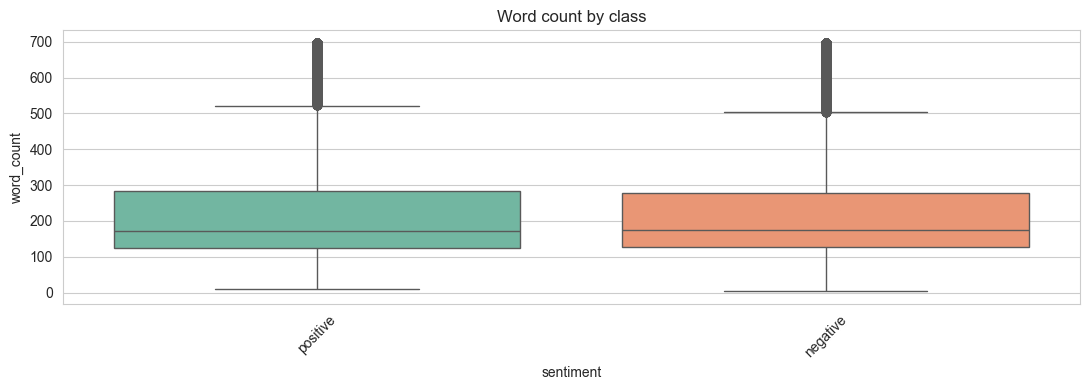

,count,mean,std,min,25%,50%,75%,max
sentiment,,,,,,,,
negative,25000.0,229.5,164.9,4.0,128.0,174.0,278.0,1522.0
positive,25000.0,232.8,177.5,10.0,125.0,172.0,284.0,2470.0


In [8]:
fig, ax = plt.subplots(figsize=(11, 4))
clip_val = df['word_count'].quantile(0.97)
sns.boxplot(x='sentiment', y=df['word_count'].clip(upper=clip_val), data=df, ax=ax, palette='Set2')
ax.set_title('Word count by class'); ax.tick_params(axis='x', rotation=45)
plt.tight_layout(); plt.show()
df.groupby('sentiment')['word_count'].describe().round(1)

## 6. Most Frequent Words (raw, pre-cleaning)

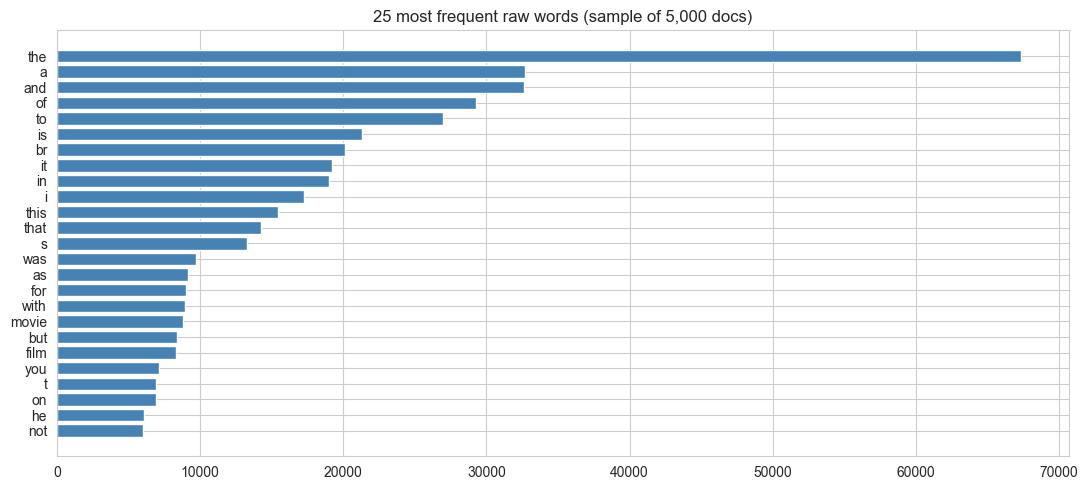

In [9]:
import re
def quick_tokens(text):
    return re.findall(r'[a-zA-Z]+', str(text).lower())
all_words = Counter()
for t in df['review'].astype(str).sample(min(len(df), 5000), random_state=42):
    all_words.update(quick_tokens(t))
common = all_words.most_common(25)
plt.figure(figsize=(11, 5))
plt.barh([w for w, _ in common][::-1], [c for _, c in common][::-1], color='steelblue')
plt.title('25 most frequent raw words (sample of 5,000 docs)')
plt.tight_layout(); plt.show()

## 7. Word Clouds per Class

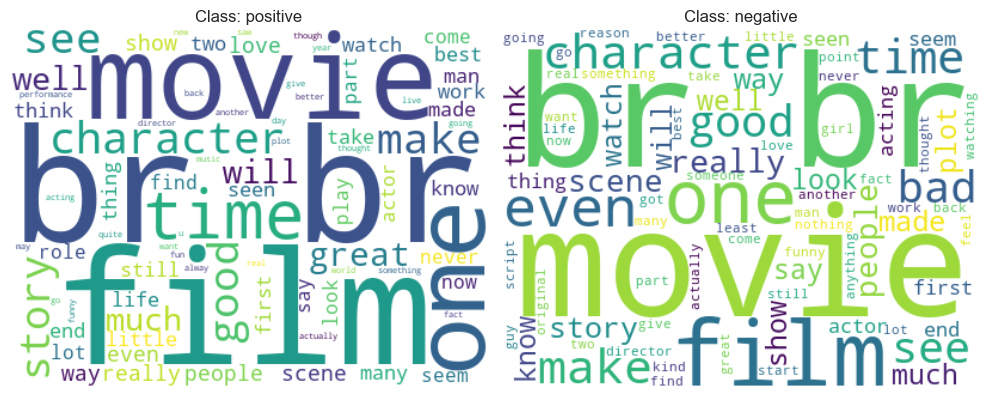

In [10]:
from wordcloud import WordCloud
classes = df['sentiment'].value_counts().index.tolist()[:4]
fig, axes = plt.subplots(1, len(classes), figsize=(5*len(classes), 4))
if len(classes) == 1: axes = [axes]
for ax, cls in zip(axes, classes):
    text = ' '.join(df[df['sentiment'] == cls]['review'].astype(str).sample(min(2000, (df['sentiment']==cls).sum()), random_state=42))
    wc = WordCloud(width=400, height=300, background_color='white', max_words=80).generate(text)
    ax.imshow(wc, interpolation='bilinear'); ax.axis('off'); ax.set_title(f'Class: {cls}')
plt.tight_layout(); plt.show()

## 9. Summary of Key Findings

In [11]:
summary = pd.DataFrame({
    'Metric': ['Total documents', 'Number of classes', 'Most common class',
               'Least common class', 'Mean word count', 'Median word count',
               'Max word count', 'Duplicate rows'],
    'Value': [
        len(df), df['sentiment'].nunique(),
        str(df['sentiment'].value_counts().idxmax()),
        str(df['sentiment'].value_counts().idxmin()),
        round(df['word_count'].mean(), 1),
        int(df['word_count'].median()),
        int(df['word_count'].max()),
        int(df.duplicated().sum()),
    ],
})
summary

,Metric,Value
0,Total documents,50000
1,Number of classes,2
2,Most common class,positive
3,Least common class,positive
4,Mean word count,231.2
5,Median word count,173
6,Max word count,2470
7,Duplicate rows,418
